# Cookie Cats A/B test: does moving the progression gate change player retention?

**Andrej Gajić** · [Case study](https://cookie-cats-ab-test-andrej.vercel.app/)

**The question.** *Cookie Cats* is a mobile puzzle game. Early on it puts up a gate that forces the player to wait, or pay, to continue. The team ran an A/B test that moved that gate from level 30 to level 40, to see whether it changed how many players came back.

**In short.** Moving the gate to level 40 reduced 7-day retention, from 19.0% to 18.2% (chi-square p = 0.0016; the control was ahead in 1,000 of 1,000 bootstrap resamples). **Recommendation: keep the gate at level 30.**

This notebook reads top to bottom. Each decision is stated before the code, with its reasoning, so the analysis can be defended rather than only run.

## Phase 0: setup

A fixed random seed everywhere, so every number below reproduces exactly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

RANDOM_STATE = 42
BLUE, RED, INK = '#2f6db0', '#c0392b', '#222'

df = pd.read_csv('cookie_cats.csv')
print('shape:', df.shape)
df.head()

shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Phase 1: load and sanity-check the data

Know the data before analysing it. This is where problems that would quietly ruin the conclusion get caught.

In [2]:
df.info()
print('\nMissing values per column:')
print(df.isna().sum())
print('\nDuplicate userids:', df['userid'].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB

Missing values per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate userids: 0


Clean: no missing values, no duplicate players. Now three checks that separate an analyst from a button-pusher.

### Check 1: sample ratio mismatch

Players are assigned to `gate_30` (control) or `gate_40` (variant) like a coin flip, so the groups should split roughly 50/50 and be otherwise identical. That "otherwise identical" is what lets an A/B test claim *cause*. If the split is badly off, the randomisation may be broken and nothing downstream can be trusted, so I check it first.

In [3]:
counts = df['version'].value_counts()
print(counts)
print(df['version'].value_counts(normalize=True).round(4))

n, k = len(df), counts['gate_30']
srm_p = stats.binomtest(k, n, 0.5).pvalue
print(f'\nSRM binomial test vs a perfect 50/50: p = {srm_p:.4f}')

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
version
gate_40    0.5044
gate_30    0.4956
Name: proportion, dtype: float64

SRM binomial test vs a perfect 50/50: p = 0.0087


**Read:** the split is 49.56 / 50.44, off by 0.44 percentage points. The test flags it (p = 0.0087), but only because n is huge. At about 90,000 players one standard deviation of random wobble is only ±0.17pp, so 0.44pp sits around 2.6 SD out. It is statistically detectable and practically trivial. The gate also cannot have caused it, since assignment happens at install, long before a player ever reaches level 30 or 40.

**Decision: proceed, and document the caveat.** Ignoring a sample ratio mismatch is how people ship conclusions from broken experiments; over-reacting to 0.44pp would throw away a good one.

### Check 2: the outlier player

Look at the extreme of engagement (`sum_gamerounds`).

In [4]:
print('max sum_gamerounds:', df['sum_gamerounds'].max())
df.sort_values('sum_gamerounds', ascending=False).head()

max sum_gamerounds: 49854


,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


One player logged **49,854 rounds in 14 days**, about 3,560 a day, which is not a real human but a bot or a logging error. It is also internally odd (`retention_1=False` but `retention_7=True`), and the next-highest player managed 2,961.

**Decision: drop this player.** It would distort engagement statistics and the prediction model. It turns out not to affect the retention rates, since one row in 90,000 cannot move a proportion, but it is still not a valid data point.

### Check 3: the engagement distribution

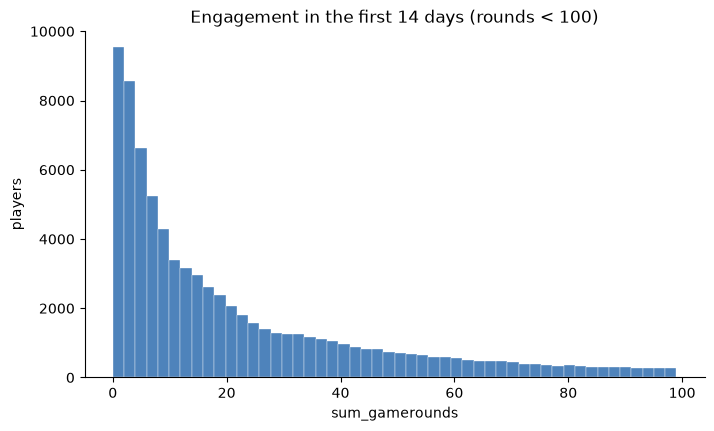

4.4% of players played 0 rounds - installed and never really started.
rows after dropping the outlier: 90188


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df.loc[df['sum_gamerounds'] < 100, 'sum_gamerounds'], bins=50,
        color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_title('Engagement in the first 14 days (rounds < 100)')
ax.set_xlabel('sum_gamerounds'); ax.set_ylabel('players')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.show()

pct0 = (df['sum_gamerounds'] == 0).mean() * 100
print(f'{pct0:.1f}% of players played 0 rounds - installed and never really started.')

df = df[df['userid'] != 6390605].copy()   # drop the outlier (decision above)
print('rows after dropping the outlier:', len(df))

A huge spike at zero: **about 4.4% of players install and never really play.** That single fact is a real player-behaviour insight, because a large part of a game's audience is decided before the design ever gets a chance. The rest is heavily right-skewed, with a few players playing enormously.

**Phase 1 summary:** 90,189 players, clean, split roughly 50/50 with a tiny documented sample ratio mismatch, one non-human outlier removed, and a large install-and-quit segment.

## Phase 2: the A/B test

### Hypothesis, stated before looking at any result

- **H0:** 7-day retention is the same in both groups; any gap is noise.
- **H1:** 7-day retention differs between the groups.

**Primary metric: `retention_7`, chosen up front.** Almost every game has decent day-1 retention, because day one is novelty and it is noisy. Day-7 retention is the signal that a lasting habit formed, which is what a game actually lives on. `retention_1` is kept as a secondary consistency check. Deciding this before seeing results is what stops cherry-picking, and it is a light form of pre-registration.

In [6]:
summary = df.groupby('version')['retention_7'].agg(['mean', 'count'])
summary

,mean,count
version,,
gate_30,0.190183,44699
gate_40,0.182000,45489


gate_30 = **19.02%**, gate_40 = **18.20%**. The control, the earlier gate, is ahead by **0.82 percentage points**. The difference is small, and the rest of Phase 2 answers the real question: is a gap this small a real signal, or just chance?

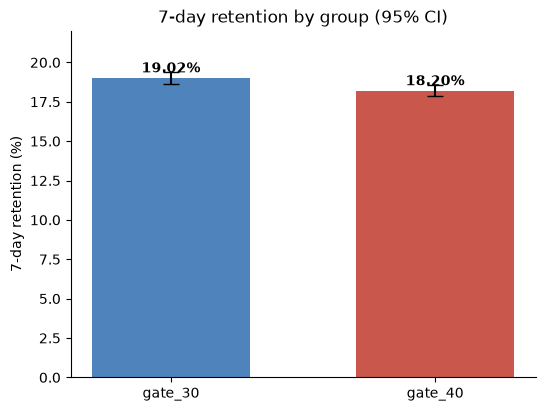

In [7]:
rates = df.groupby('version')['retention_7'].mean()
ns = df.groupby('version')['retention_7'].count()
ci = 1.96 * np.sqrt(rates * (1 - rates) / ns)   # 95% CI for a proportion

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(rates.index, rates.values * 100, yerr=ci.values * 100, capsize=6,
       color=[BLUE, RED], alpha=0.85, width=0.6)
for i, v in enumerate(rates.values):
    ax.text(i, v * 100 + 0.35, f'{v*100:.2f}%', ha='center', fontweight='bold')
ax.set_ylabel('7-day retention (%)'); ax.set_ylim(0, 22)
ax.set_title('7-day retention by group (95% CI)')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.show()

### Is it real? The chi-square test, with a z-test as a cross-check

Retention is a yes/no outcome per player, so this compares two proportions. The chi-square test of independence on the 2×2 table asks whether returning is linked to the group a player was in, or independent of it. The two-proportion z-test answers the same thing a different way. For a 2×2 they are the same mathematics (z² ≈ chi²), so agreement is a sanity check on the setup rather than new evidence.

In [8]:
ct = pd.crosstab(df['version'], df['retention_7'])
print(ct, '\n')

chi2, p, dof, expected = chi2_contingency(ct)
print(f'chi-square:  chi2 = {chi2:.3f}, dof = {dof}, p = {p:.5f}')

succ = df.groupby('version')['retention_7'].sum().loc[['gate_30', 'gate_40']].values
nobs = df.groupby('version')['retention_7'].count().loc[['gate_30', 'gate_40']].values
z, pz = proportions_ztest(succ, nobs)
print(f'z-test:      z = {z:.3f},  p = {pz:.5f}   (z^2 = {z**2:.3f} ~ chi2)')

retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279 

chi-square:  chi2 = 9.915, dof = 1, p = 0.00164
z-test:      z = 3.157,  p = 0.00159   (z^2 = 9.969 ~ chi2)


**p = 0.0016.** In plain words: if the two gates truly had identical retention, a gap at least this big would appear by chance only about 0.16% of the time, roughly once in 600 experiments. That is a poor explanation for what we see, so the difference is real rather than noise. The z-test lands on the same p, confirming it.

The lesson worth keeping: 0.82pp *looks* small, but "small to a human" is not the question. "Bigger than the noise" is, and at this sample size the noise is tiny.

### How big, and how sure? The bootstrap

A p-value is one number, and it only answers "real or not". A bootstrap shows the range of plausible differences and how confident we can be. Resample the players with replacement 1,000 times, recompute the gap each time, and look at the spread. This is what you actually hand a product manager: not "significant", but "here is how sure, and roughly how much".

observed gap (gate_30 - gate_40): +0.82 pp
control ahead in 1000/1000 resamples
95% bootstrap CI for the gap: [+0.32, +1.34] pp


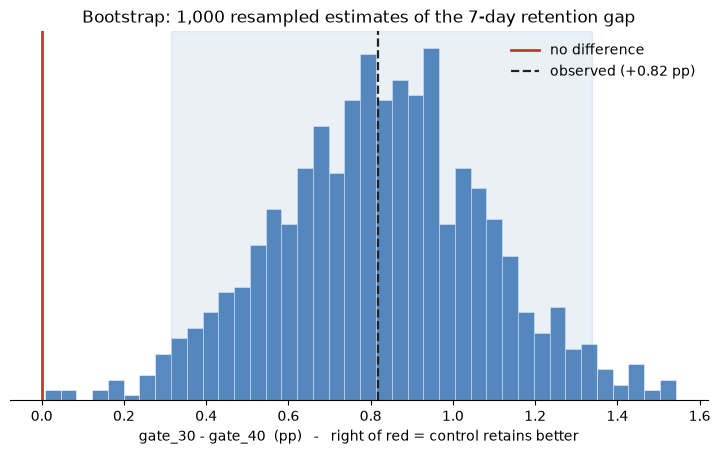

In [9]:
r7   = df['retention_7'].to_numpy().astype(float)
is30 = (df['version'].to_numpy() == 'gate_30')
n    = len(df)
obs  = r7[is30].mean() - r7[~is30].mean()

rng = np.random.default_rng(RANDOM_STATE)
boot = np.empty(1000)
for i in range(1000):
    idx = rng.integers(0, n, n)
    s7, s30 = r7[idx], is30[idx]
    boot[i] = s7[s30].mean() - s7[~s30].mean()

boot_pp = boot * 100
ahead   = int((boot > 0).sum())
lo, hi  = np.percentile(boot_pp, [2.5, 97.5])
print(f'observed gap (gate_30 - gate_40): {obs*100:+.2f} pp')
print(f'control ahead in {ahead}/1000 resamples')
print(f'95% bootstrap CI for the gap: [{lo:+.2f}, {hi:+.2f}] pp')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(boot_pp, bins=40, color=BLUE, alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(0, color=RED, lw=2, label='no difference')
ax.axvline(obs * 100, color=INK, ls='--', lw=1.6, label=f'observed ({obs*100:+.2f} pp)')
ax.axvspan(lo, hi, color=BLUE, alpha=0.10)
ax.set_title('Bootstrap: 1,000 resampled estimates of the 7-day retention gap')
ax.set_xlabel('gate_30 - gate_40  (pp)   -   right of red = control retains better')
ax.set_yticks([]); ax.legend(frameon=False)
for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)
plt.show()

The whole cloud sits to the right of zero. The control was ahead in **1,000 of 1,000** resamples, and the 95% interval, **+0.32 to +1.34pp**, never crosses zero. So the direction is not in doubt, while the size is modest, between a third and one-and-a-third of a point. A small effect, with a direction that is not in doubt.

### Secondary check: `retention_1`

Does the shorter horizon agree? Consistency strengthens the story, and a conflict would need an honest explanation.

In [10]:
s1 = df.groupby('version')['retention_1'].mean()
chi2_1, p1, _, _ = chi2_contingency(pd.crosstab(df['version'], df['retention_1']))
print(f"gate_30: {s1['gate_30']*100:.2f}%   gate_40: {s1['gate_40']*100:.2f}%")
print(f'gap (30-40): {(s1["gate_30"]-s1["gate_40"])*100:+.2f} pp   |   chi-square p = {p1:.4f}')

gate_30: 44.82%   gate_40: 44.23%
gap (30-40): +0.59 pp   |   chi-square p = 0.0750


Day 1 points the **same way** (gate_30 ahead by 0.59pp) but is **not** significant (p = 0.075). That is exactly consistent with day 1 being noisier, and it is why day 7 was chosen as primary in advance. The same direction on both horizons is a coherent story, with no cherry-picking.

### Recommendation

> **Question.** I tested whether moving the game's first gate from level 30 to level 40 changed player retention, using 7-day retention as the primary metric, since day 1 is noisier and a weaker sign of a lasting habit.
>
> **Finding.** Keeping the gate at level 30 retained more players: 19.0% against 18.2% at day 7, a 0.8-point drop for gate_40, or about 4% of the control's retention. It is statistically solid (chi-square p = 0.0016; the control ahead in all 1,000 bootstrap resamples, 95% interval +0.3 to +1.3pp). Day 1 pointed the same way but was not significant, consistent with it being noisier. The small per-player gap still matters at a scale of millions of players.
>
> **Recommendation. Keep the gate at level 30, and do not ship the move to 40.**
>
> **Confidence and caveats.** I am very confident in the direction, less certain of the exact size (0.3 to 1.3pp), and least certain about the reason: a forced-break effect is a plausible explanation, not something this test proved. Before calling it final I would check a longer time window, segment casual against heavy players, and confirm the gate is not trading retention for revenue, since the gate is also where players pay to skip, a lever this retention-only test cannot see.

## Phase 3: a retention prediction model, and a lesson in leakage

Can I predict `retention_7` from what is known about a player early on? A small, interpretable baseline, followed by an honest audit of it.

**Why logistic regression?** The target is binary, and its coefficients are readable: each one pushes the return probability up or down. Start simple.

**Why `stratify`?** Only about 18.6% of players return by day 7, so the classes are imbalanced. Stratifying keeps that ratio in both train and test, so the test set mirrors reality.

**Why ROC-AUC rather than accuracy?** A lazy model that always predicts "won't return" scores about 81% accuracy while being useless. AUC measures ranking ability, and imbalance cannot flatter it.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

df['version_gate40'] = (df['version'] == 'gate_40').astype(int)
df['retention_1_int'] = df['retention_1'].astype(int)
y = df['retention_7'].astype(int)

def fit_report(features):
    X = df[features].astype(float)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=y)
    sc = StandardScaler().fit(Xtr)
    m = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), ytr)
    proba = m.predict_proba(sc.transform(Xte))[:, 1]
    auc = roc_auc_score(yte, proba)
    acc = (m.predict(sc.transform(Xte)) == yte).mean()
    return m, auc, acc

feat_all = ['sum_gamerounds', 'retention_1_int', 'version_gate40']
model, auc, acc = fit_report(feat_all)
print(f'ROC-AUC:            {auc:.4f}')
print(f'accuracy:           {acc:.4f}   (lazy always-no baseline: {1-y.mean():.4f})')
print('\nstandardized coefficients (bigger |value| = stronger driver):')
for f, c in sorted(zip(feat_all, model.coef_[0]), key=lambda t: -abs(t[1])):
    print(f'   {f:18s} {c:+.3f}')

ROC-AUC:            0.8811
accuracy:           0.8686   (lazy always-no baseline: 0.8139)

standardized coefficients (bigger |value| = stronger driver):
   sum_gamerounds     +1.884
   retention_1_int    +0.337
   version_gate40     -0.035


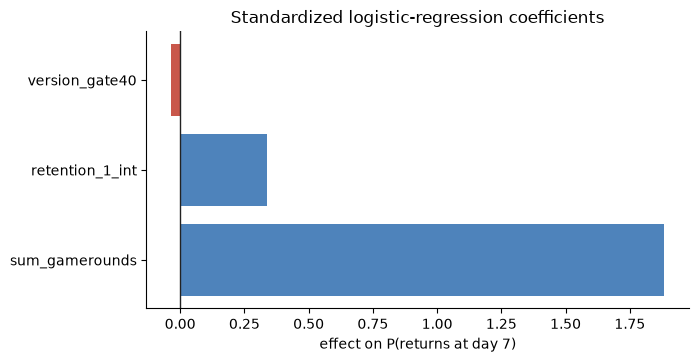

In [12]:
coefs = dict(zip(feat_all, model.coef_[0]))
fig, ax = plt.subplots(figsize=(7, 3.6))
names = list(coefs.keys()); vals = [coefs[k] for k in names]
ax.barh(names, vals, color=[BLUE if v >= 0 else RED for v in vals], alpha=0.85)
ax.axvline(0, color=INK, lw=1)
ax.set_title('Standardized logistic-regression coefficients')
ax.set_xlabel('effect on P(returns at day 7)')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.show()

`sum_gamerounds` dominates, at five to six times the others, while `version_gate40` is effectively zero. The gate barely predicts an individual player's retention, which fits the tiny aggregate effect found earlier. AUC = 0.88 looks strong.

**But be suspicious of a number that good.** `sum_gamerounds` counts rounds over the first **14 days**, while the target is retention at **day 7**, so the feature covers a window that runs past the thing it predicts. A player with 200 rounds over a fortnight was obviously still around at day 7, so the feature partly contains the answer. That is **data leakage**. Let me measure how much of the 0.88 was really leakage, by dropping it and keeping only genuinely early signals.

In [13]:
_, auc_noleak, _ = fit_report(['retention_1_int', 'version_gate40'])
print(f'WITH sum_gamerounds (leaky):    AUC = {auc:.4f}')
print(f'WITHOUT it (honest early only): AUC = {auc_noleak:.4f}')
print(f'inflation from the leaky feature: {auc - auc_noleak:.4f}')

WITH sum_gamerounds (leaky):    AUC = 0.8811
WITHOUT it (honest early only): AUC = 0.7160
inflation from the leaky feature: 0.1652


Removing the leaking feature drops AUC from **0.88 to 0.72**, and that 0.16 was the leak. **0.72 is the honest, deployable number**, since `retention_1` legitimately predicts `retention_7` because day 1 genuinely comes first. The takeaway outlives the score: always ask whether a feature would actually be available, and would not already encode the answer, at the moment you would make the prediction.

## Limitations, and what I would check next

- **Segment by engagement.** Do casual and heavy players react to the gate differently? An average can hide two opposite effects.
- **A longer window.** This only sees up to day 7; a novelty effect could fade, or grow, by day 30 or 90.
- **Revenue, not just retention.** The gate is a monetisation lever, since players pay to skip. gate_40 could earn more per player even while slightly fewer return, and this dataset has no revenue column, so the trade-off is unmeasured here.
- **A power analysis**, confirming the sample was large enough to detect the effect size I cared about. Here n was clearly ample.

**Bottom line:** moving the gate to level 40 reliably reduced 7-day retention, so the recommendation is to keep it at level 30, while flagging that a full decision should also weigh revenue.